## BIS ADVANCED

In [1]:
import sys
import os
import glob
import pandas as pd
import numpy as np
from datetime import datetime

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import struct

import funciones_aux as fau

import funciones_dsa as fun_dsa


from matplotlib.colors import LinearSegmentedColormap, PowerNorm

### General todos los archivos

In [2]:
# Exploración carpeta raíz datos advanced

ruta_base_advanced = "../data/data_bis_advanced"

"""for raiz, dirs, files in os.walk(ruta_base_advanced):
    print(f"\nCarpeta: {raiz}")
    print("Subcarpetas:", dirs)
    print("Archivos:", files)"""

'for raiz, dirs, files in os.walk(ruta_base_advanced):\n    print(f"\nCarpeta: {raiz}")\n    print("Subcarpetas:", dirs)\n    print("Archivos:", files)'

In [3]:
ruta_base_advanced = "../data/data_bis_advanced"

"""
os.path.join: construye ruta para el SO
**: buscar en todas las subcarpetas del data_bis_advanced
recursive = True: para que mire en carpeta tras carpeta
    Si no está, ** no te recorre la estructura
glob.glob(...): función para buscar archivos por patrón
"""
todos_archivos_advanced = glob.glob(os.path.join(ruta_base_advanced, "**", "L03041035.*"), recursive=True)

"""for archivo in todos_archivos_advanced:
    probar_apertura_texto(archivo, 5)"""

'for archivo in todos_archivos_advanced:\n    probar_apertura_texto(archivo, 5)'

 ## Archivo .f_a

### Directamente sin pasar por el .csv

In [4]:
archivos_fa = fau.localizar_archivos(ruta_base_advanced, "DH*", "*.f_a")
ruta_fa = archivos_fa[0]
print("Archivo seleccionado:", ruta_fa)

#vista_preeliminar_texto(ruta_fa, 10)

Se han encontrado 2 archivos *.f_a
Archivo seleccionado: ../data/data_bis_advanced\M-TA6m-03041035\DH03041035\L03041035.f_a


### Carga de archivo
Cargar el archivo .f_a del monitor BIS como un fichero de texto estructurado. 

El separador principal es el carácter |, que delimita una columna temporal (Time) y una columna con la información espectral (Spectra).

La columna Spectra contiene 60 valores por instante temporal, separados por comas, que corresponden a las bandas de frecuencia de la matriz DSA. Estas bandas abarcan desde 0.5 Hz hasta 30 Hz con una resolución de 0.5 Hz.

Una vez expandida la columna espectral, se obtiene una matriz de dimensiones tiempo × frecuencia, que puede representarse como imagen en forma de mapa de calor. En dicha representación, el eje horizontal corresponde al tiempo, el eje vertical a la frecuencia y el color a la intensidad espectral.

La resolución temporal real se verifica calculando la diferencia entre marcas temporales consecutivas. En los datos analizados, esta separación es de 1 segundo por fila.

Los valores espectrales aparecen almacenados como enteros escalados. Tras aplicar un factor de corrección de 1/100, el mapa de color se interpreta como potencia espectral en dB, pendiente de confirmación definitiva con la documentación técnica del dispositivo.

In [5]:
tiempo, dsa = fau.cargar_fa_directo(ruta_fa, escalar_db=True)

print("Dimensiones de la matriz:", dsa.shape)
print("Frecuencias:", dsa.columns.min(), "a", dsa.columns.max(), "Hz")

# salto entre una banda de frecuencia y la siguiente. La diferencia entre columnas consecutivas es 0.5
print("Resolución en frecuencia:", dsa.columns[1] - dsa.columns[0], "Hz")

Dimensiones de la matriz: (2119, 60)
Frecuencias: 0.5 a 30.0 Hz
Resolución en frecuencia: 0.5 Hz


In [6]:
"""
Si se quiere recomponer el df final en el que hay 61 columnas:
 - 1º: Time. Se fuerza a que cuando se convierta en columna se llame Time
 - siguientes: frecuencias de 0.5 Hz a 30 Hz

"""
df_final = pd.concat([tiempo.rename("Time"), dsa], axis=1)
#print(df_final)


## Archivo .spa

### BIS Unilateral: canales

**Mapa de pegatinas**
 - Pegatina 1 (Referencia): Va en el centro de la frente. Es el punto "cero" o base contra el que se va a comparar todo lo demás.
 - Pegatina 2 (Tierra / Ground): Va al lado de la 1. No recoge ondas cerebrales, solo sirve para absorber el "ruido" eléctrico de tu cuerpo (como un pararrayos) para que la señal sea limpia.
 - Pegatina 3 (Explorador 1): Va hacia la zona temporal (sien).
 - Pegatina 4 (Explorador 2): Va un poco más al extremo, justo por encima de la ceja/ojo.


### Canales

**Canal 1 (Ch 1 -> variables sin sufijo)**
 - Corresponde a la señal principal captada por la primera zona de exploración de tu pegatina.
 - Datos válidos y reales para casi todo. Número BIS (DB13U01 o similar), tasa de supresión (SR),  EMG, y la calidad de señal (SQI e impedancia).
 
**Canal 2 (Ch 2 -> variables terminadas en _2)**
 - Corresponde a la señal captada por la segunda zona de exploración de la pegatina.
 - El algoritmo no suele calcular variables matemáticas complejas (como el número BIS o el SEF) solo para este segundo canal físico, por lo que esos campos aparecerán con el código de error -3276.8 (dato inválido).
 - Las únicas variables con números reales aquí serán las físicas de los electrodos, como la Calidad de la Señal (SQI10_2) y la Impedancia.
 
**Canal Combinado (Ch12 -> variables terminadas en _3)**
 - Este no es un electrodo físico real. Es un "canal virtual" o derivado que el monitor crea combinando la información del Canal 1 y del Canal 2.
 - Contiene los valores finales procesados que el monitor muestra en la pantalla.
 - Los valores del Canal 12 (terminados en _3) suelen ser idénticos a los del Canal 1 (sin sufijo). El algoritmo vuelca el cálculo definitivo en ambos sitios.

En este caso unilateral se pueden limpiar los campos acabados en _2 y _3.
 - Al eliminar las columnas _3 (Canal 12): Como es un combinado de los canales 1 y 2 los valores son idénticos al canal 1.
 - Al eliminar las columnas _2 (Canal 2): Las variables del canal 2 están en nulo salvo la calidad de la señal y la impedancia.
 

------------------------------------------------------------------------------------------------

El Canal 1 (Ch 1): Se forma midiendo la diferencia de electricidad entre la Pegatina 3 y la Pegatina 1. Este es el circuito principal que capta la actividad de la corteza frontal.

El Canal 2 (Ch 2): Se forma midiendo la diferencia entre la Pegatina 4 y la Pegatina 1. Este circuito está más cerca del ojo, por lo que suele captar mejor los parpadeos (artefactos) y sirve de apoyo.

------------------------------------------------------------------------------------------------

**Para hacer un análisis de datos o hacer gráficas se pueden mantener únicamente los campos principales que no tienen sufijo y corresponden al Channel 1.**


In [7]:
ruta_spa_unilat = "../data/data_bis_advanced/M-TA6m-03041035/DH03041035/L03041035.spa"
df_spa_unilat = fau.procesar_spa(ruta_spa_unilat)

#display(df_spa_unilat.head())
print(df_spa_unilat.shape)
print(df_spa_unilat.columns.tolist())

(2119, 54)
['Time', 'SpSmooth', 'BiSmooth', 'LoFilter', 'NotFiltr', 'HiFilter', 'PIC_ID', 'SR12', 'SEF08', 'MEDFRQ08', 'BISBIT00', 'DB13U01', 'DB11U04', 'B34U05', 'TOTPOW08', 'EMGLOW01', 'SQI10', 'IMPEDNCE', 'ARTF2', 'BURST', 'ST', 'SR12_2', 'SEF08_2', 'MEDFRQ08_2', 'BISBIT00_2', 'DB13U01_2', 'DB11U04_2', 'B34U05_2', 'TOTPOW08_2', 'EMGLOW01_2', 'SQI10_2', 'IMPEDNCE_2', 'ARTF2_2', 'BURST_2', 'ST_2', 'SR12_3', 'SEF08_3', 'MEDFRQ08_3', 'BISBIT00_3', 'DB13U01_3', 'DB11U04_3', 'B34U05_3', 'TOTPOW08_3', 'EMGLOW01_3', 'SQI10_3', 'IMPEDNCE_3', 'ARTF2_3', 'BURST_3', 'ST_3', 'C1POSIMP', 'C1NEGIMP', 'GNDIMP', 'C2POSIMP', 'C2NEGIMP']


In [8]:
"""display(df_spa_unilat.iloc[200:240: 2, :20])
display(df_spa_unilat.iloc[200: 240: 2, 20:32])
display(df_spa_unilat.iloc[200: 240: 2, 32:43])
display(df_spa_unilat.iloc[200: 240: 2, 43:])"""

'display(df_spa_unilat.iloc[200:240: 2, :20])\ndisplay(df_spa_unilat.iloc[200: 240: 2, 20:32])\ndisplay(df_spa_unilat.iloc[200: 240: 2, 32:43])\ndisplay(df_spa_unilat.iloc[200: 240: 2, 43:])'

### Cosas de las variables (BIS_Export Data Technical Specification):

Los valores de -327.7, -3276.8, -32768.0 y 3276.7 no son salidas válidas y, por lo tanto, no deben utilizarse. Los valores pueden invalidarse debido a un SQI bajo, una función no compatible u otros motivos.

La impedancia igual a 32768.0 representa valores de impedancia fuera de rango durante la comprobación periódica de tierra y no debe utilizarse.

 - SpSmooth: Extraído del mensaje de variables procesadas con configuración de suavizado espectral.
     - Formato: 
                0 = 0 seconds
                1 = 5 seconds
                2 = 10 seconds
                3 = 30 seconds
                4 = 60 seconds
 - BiSmooth: Extraído del mensaje de variables procesadas con configuración de suavizado biespectral.
     - Formato:
                0 = 15 seconds
                1 = 30 seconds
                2 = 60 seconds
                3 = 10 seconds
                
 - LoFilter: Mensaje extraído de las variables procesadas con configuración de filtro pasa baja.
     - Formato:
                0 = 0.25 Hz
                1 = 1.00 Hz
                2 = 2.00 Hz
                3 = 2.50 Hz
                
 - NotFilter: Extraído del mensaje de variables procesadas con configuración de filtro de muesca (Notch Filter).
     - Formato:
                0 = ninguno (none)
                1 = 50 Hz
                2 = 60 Hz
                3 = 50 y 60 Hz

 - HiFilter: Extraído del mensaje de variables procesadas con configuración de filtro pasa alta (High Filter).
      - Formato:
                0 = ninguno (none)
                1 = 30 Hz
                2 = 50 Hz
                3 = 70 Hz

 - PIC_ID: ID del cable de interfaz del paciente. Los sensores inteligentes combinan el valor del cable del sensor junto con un valor correspondiente al tipo de sensor.
      - Formato:
                Tipos de sensor = 1 - 14
                Cable inteligente = 7
                (ej: PIC_ID 27 = Sensor Quatro)
                
 - Suppression Ratio (SR): El porcentaje de épocas en los últimos 63 segundos en los que la señal EEG se considera suprimida.
     - Formato: 
                0.0 - 100.0%


 - Spectral Edge Frequency (SEF): La frecuencia en la cual el 95% de la potencia total se encuentra por debajo de ella y el 5% se encuentra por encima.
     - Formato: 
                0.5 - 30.0 Hz


 - BISBIT: Códigos que representan características del algoritmo BIS que son activadas por parámetros de los datos del EEG; útiles para la resolución de problemas por parte del personal técnico.
     - Formato: 
                Número hexadecimal de 4 dígitos alineado a la derecha.


 - Bispectral Index (BIS) / B34... / DB1...: El resultado de un análisis discriminante multivariante que cuantifica las propiedades biespectrales generales (frecuencia, potencia y fase) en todo el rango de frecuencias.
     - Formato: 
                0.0 - 100.0


 - Alternate BIS Value / Second Alternate BIS Value: Valor BIS alternativo y segundo valor BIS alternativo.
     - Formato: 
                0.0 - 100.0


 - TOTPOW: Una medida de la potencia total absoluta en el rango de frecuencias de 0.5 a 30.0 Hz.
     - Formato: 
                40.0 - 100.0 dB (con respecto a 0.0001 µV²).


 - EMG: La potencia absoluta en el rango de 70-110 Hz. Toda la detección de artefactos está desactivada para esta variable.
     - Formato: 
                30.0 - 80.0 dB (con respecto a 0.0001 µV²).


 - Signal Quality Index (SQI): Una medida de la calidad de la señal para la(s) fuente(s) del canal EEG que se calcula basándose en datos de impedancia, artefactos y otras variables. No se ve afectado por la tasa de supresión (SR).
     - Formato: 
                0.0 - 100.0%


 - IMPEDNCE: El valor de impedancia para ese canal según lo detectado por la comprobación continua de impedancia.
     - Formato: 
                Valores en Kohms (kiloohmios).


 - ARTF2: Marcas de artefactos (artifact flags) o códigos de diagnóstico para ese canal. Los códigos representan varias condiciones de estado de hardware y software.
     - Formato: 
                8 dígitos hexadecimales.


 - BURST: Recuento de ráfagas (Burst Count), un medio alternativo para medir la supresión del EEG. Solo es válido cuando se utiliza un sensor Extend o Bilateral.
     - Formato: 
                0.0 - 30.0 ráfagas/minuto (bursts/minute).


 - RESVR: Variable reservada.


 - C1POSIMP (et al.): Valores que representan la impedancia durante una Comprobación de Sensor (Sensor Check) o Comprobación de Tierra (Ground Check) para los terminales Positivos y Negativos de cada canal, y también para el terminal de Tierra.
     - Formato: 
                Todos los valores están en Ohmios (Ohms).


 - ASYM: Asimetría o el porcentaje de potencia de EEG presente en los hemisferios izquierdo o derecho.
         (Total Power Left / Total Power Left + Right) * 1000
     - Formato: 
                0.0 - 100.0%
                inválido: -3276.8
                ASYM solo es válido para el Channel 1


 - SBIS: Un índice de variabilidad del BIS calculado para cada lado de la cabeza. Representa la desviación estándar sobre el último minuto.
     - Formato: 
                0.0 a 10.0
                inválido: -3276.8


 - SEMG: Un índice de variabilidad EMG calculado para cada lado de la cabeza. Representa la desviación estándar de los valores EMG sobre el último minuto.
     - Formato: 
                 0.0 a 10.0
                 inválido: -3276.8


 - BILBITS: Bits bilaterales complementarios.
     - Formato: 
                 Número hexadecimal de 2 dígitos alineado a la derecha.
                 Bit 0: 1 indica Sensor Bilateral
                 Bit 1: 0 indica hemisferio izquierdo
                 Bit 1: 1 indica hemisferio derecho


## Sacar Matriz Espectral de .f_a y .spa

### vista tipo PDF BIS

Esta vista intenta parecerse al PDF:

 - tiempo en vertical
 - frecuencia en horizontal
 - mismo mapa de color.
 - líneas discontinuas de bandas EEG


In [9]:
matriz = dsa.values
print(matriz)

[[ 0.    0.    0.   ...  0.    0.    0.  ]
 [ 0.    0.    0.   ...  0.    0.    0.  ]
 [ 0.    0.    0.   ...  0.    0.    0.  ]
 ...
 [90.25 96.09 94.11 ... 78.68 78.69 78.49]
 [90.11 96.01 94.11 ... 78.38 78.48 78.09]
 [89.97 95.94 94.13 ... 78.11 78.27 77.73]]


In [10]:
print("Valor mínimo:", dsa.min().min())
print("Valor máximo:", dsa.max().max())

Valor mínimo: 0.0
Valor máximo: 103.02


In [11]:
print(tiempo)

0      2026-03-04 10:35:21
1      2026-03-04 10:35:22
2      2026-03-04 10:35:23
3      2026-03-04 10:35:24
4      2026-03-04 10:35:25
               ...        
2114   2026-03-04 11:10:35
2115   2026-03-04 11:10:36
2116   2026-03-04 11:10:37
2117   2026-03-04 11:10:38
2118   2026-03-04 11:10:39
Name: Time, Length: 2119, dtype: datetime64[ns]


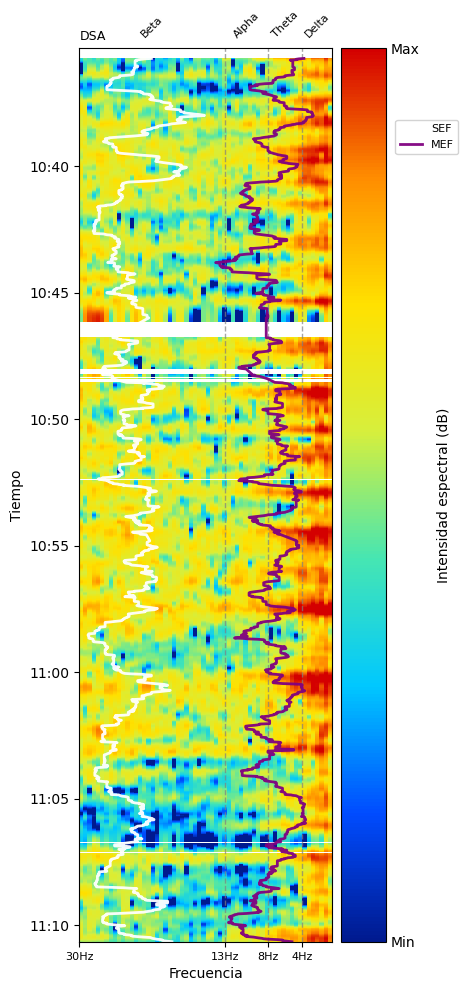

In [12]:
df_merge_vertical = fun_dsa.alinear_spa_con_tiempo(tiempo, df_spa_unilat)
sef_vertical = df_merge_vertical["SEF08"]
mf_vertical = df_merge_vertical["MEDFRQ08"]

dsa_plot_vertical, mask_total_vertical = fun_dsa.preparar_dsa_para_plot(tiempo, dsa, df_merge_vertical)
matriz_vertical, vmin, vmax, norm, cmap = fun_dsa.preparar_escala_color_dsa(dsa_plot_vertical)

fun_dsa.plot_dsa_pdf_con_spa(tiempo, dsa, df_spa_unilat)

### vista horizontal tipo análisis

In [54]:
df_merge_hor = fun_dsa.alinear_spa_con_tiempo(tiempo, df_spa_unilat)
sef_hor = df_merge_hor["SEF08"]
mf_hor = df_merge_hor["MEDFRQ08"]

dsa_plot_hor, mask_total_hor = fun_dsa.preparar_dsa_para_plot(tiempo, dsa, df_merge_hor)
matriz_hor, vmin, vmax, norm, cmap = fun_dsa.preparar_escala_color_dsa(dsa_plot_hor)

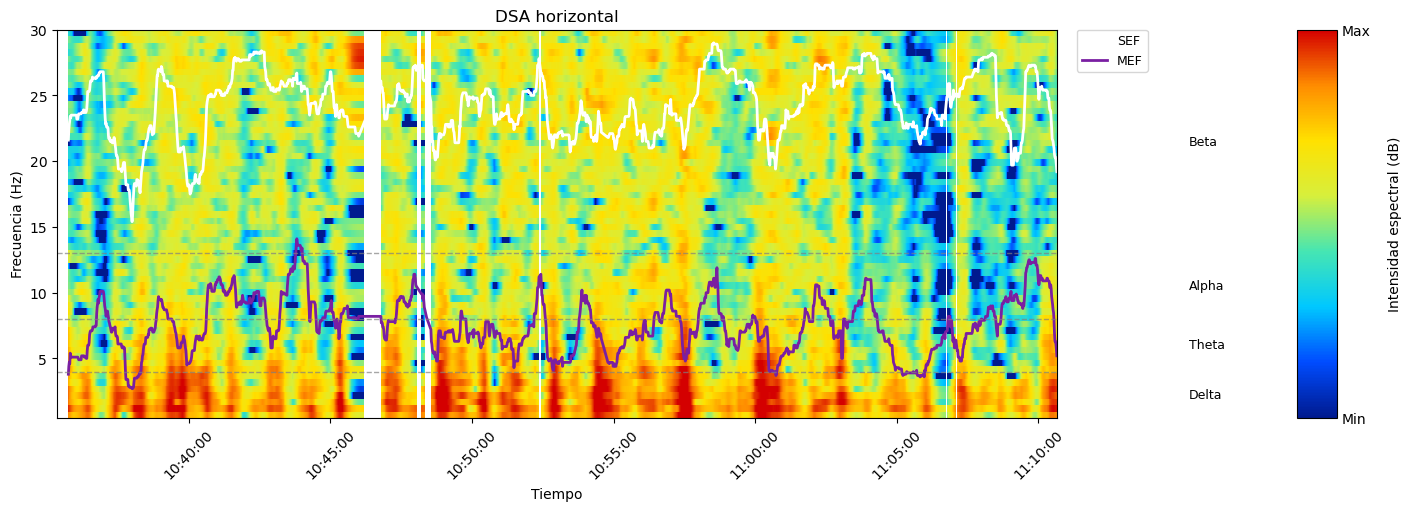

In [55]:
# Escala de color a partir de la DSA ya enmascarada
_, vmin, vmax, norm, cmap = fun_dsa.preparar_escala_color_dsa(dsa_plot_hor)

# Para horizontal: filas = frecuencia, columnas = tiempo
matriz_hor = dsa_plot_hor.T.values

# 2) Crear figura
fig = plt.figure(figsize=(14, 5), constrained_layout=True)
gs = fig.add_gridspec(1, 3, width_ratios=[20, 1.5, 0.8], wspace=0.08)

ax = fig.add_subplot(gs[0, 0])       # DSA
ax_band = fig.add_subplot(gs[0, 1])  # nombres de bandas
cax = fig.add_subplot(gs[0, 2])      # colorbar

# 3) Límites reales de ejes
x0 = mdates.date2num(tiempo.iloc[0])
x1 = mdates.date2num(tiempo.iloc[-1])
y0 = dsa_plot_hor.columns.min()
y1 = dsa_plot_hor.columns.max()

# 4) Dibujar la DSA horizontal
im = ax.imshow(
    matriz_hor,
    aspect="auto",
    origin="lower",
    extent=[x0, x1, y0, y1],
    cmap=cmap,
    norm=norm,
    interpolation="nearest"
)

# 5) Curvas SEF y MEF
mask_sef_hor = sef_hor.notna() & (sef_hor >= 0.5) & (sef_hor <= 30)
mask_mf_hor = mf_hor.notna() & (mf_hor >= 0.5) & (mf_hor <= 30)

ax.plot(
    tiempo[mask_sef_hor],
    sef_hor[mask_sef_hor],
    color="white",
    linewidth=2.0,
    label="SEF"
)

ax.plot(
    tiempo[mask_mf_hor],
    mf_hor[mask_mf_hor],
    color="#7a1fa2",
    linewidth=2.0,
    label="MEF"
)

ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0,
    frameon=True,
    facecolor="white",
    framealpha=0.8,
    fontsize=9
)

# 6) Formato de ejes
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
plt.setp(ax.get_xticklabels(), rotation=45)

ax.set_xlabel("Tiempo")
ax.set_ylabel("Frecuencia (Hz)")
ax.set_title("DSA horizontal")

# 7) Líneas de separación de bandas
for f in [4, 8, 13]:
    ax.axhline(f, color="gray", linestyle="--", linewidth=1, alpha=0.7)

# 8) Eje lateral con nombres de bandas
ax_band.set_ylim(y0, y1)
ax_band.set_xlim(0, 1)
ax_band.axis("off")

bandas = {
    "Delta": (0.5 + 4) / 2,
    "Theta": (4 + 8) / 2,
    "Alpha": (8 + 13) / 2,
    "Beta":  (13 + 30) / 2,
}

for nombre, ypos in bandas.items():
    ax_band.text(0.05, ypos, nombre, va="center", ha="left", fontsize=9)

# 9) Barra de color
cbar = fig.colorbar(im, cax=cax)
cbar.set_ticks([vmin, vmax])
cbar.set_ticklabels(["Min", "Max"])
cbar.ax.tick_params(length=0)
cbar.set_label("Intensidad espectral (dB)", rotation=90, labelpad=12)

plt.show()

### Unidades del mapa de color

Los valores espectrales están almacenados escalados por un factor 100 y, tras corregirlo, el mapa de color representa potencia espectral en dB.



### Resolución temporal real

La resolución temporal real del archivo .f_a es de 1 segundo por fila.

### Comportamiento de distintas variables a lo largo del tiempo

Para ver qué variables afectan a la pérdida de información o cómo responden a dicha pérdida:
 - SQI10 y TOTPOW08: afectan a la calidad y pérdida de información
 - DB13U01: se ve que se pierde la información
 
 
El análisis conjunto de los archivos .f_a y .spa sugiere que las bandas blancas de la DSA no corresponden simplemente a ausencia de filas en la matriz espectral, sino a tramos que el sistema considera no válidos. 

En los datos analizados, estos tramos coinciden con descensos de SQI10 por debajo de aproximadamente 14 y con la aparición del valor centinela -327.7 en TOTPOW08 y -3276.8 DB13U01, interpretado como valor no válido o no disponible. 

Esta interpretación es coherente con el hecho de que el archivo .spa contiene variables procesadas del sistema y con la definición de la DSA como representación de la potencia EEG mediante color.

In [15]:
"""plt.figure(figsize=(12,4))
plt.plot(df_spa_unilat["Time"], pd.to_numeric(df_spa_unilat["SQI10"], errors="coerce"))
plt.title("SQI10 a lo largo del tiempo")
plt.ylabel("SQI10")
plt.xlabel("Tiempo")
plt.show()"""


"""plt.figure(figsize=(12,4))
plt.plot(df_spa_unilat["Time"], pd.to_numeric(df_spa_unilat["TOTPOW08"], errors="coerce"))
plt.title("TOTPOW08 a lo largo del tiempo")
plt.ylabel("TOTPOW08")
plt.xlabel("Tiempo")
plt.show()"""


"""plt.figure(figsize=(12,4))
plt.plot(df_spa_unilat["Time"], pd.to_numeric(df_spa_unilat["DB13U01"], errors="coerce"))
plt.title("DB13U01 a lo largo del tiempo")
plt.ylabel("DB13U01")
plt.xlabel("Tiempo")
plt.show()"""

'plt.figure(figsize=(12,4))\nplt.plot(df_spa_unilat["Time"], pd.to_numeric(df_spa_unilat["DB13U01"], errors="coerce"))\nplt.title("DB13U01 a lo largo del tiempo")\nplt.ylabel("DB13U01")\nplt.xlabel("Tiempo")\nplt.show()'

### Comprobación de valores de campos pre-limpieza

In [16]:
#resultado_sqi = buscar_filas_por_valor(df_spa_unilat, "SQI10", "between", 14, 15)

In [17]:
#resultado_sqi[["Time", "SQI10", "SQI10_2", "SQI10_3", "TOTPOW08", "TOTPOW08_2", "TOTPOW08_3"]]

In [18]:
#resultado_sqi[["Time", "SQI10", "SQI10_2", "SQI10_3", "EMGLOW01", "EMGLOW01_2", "EMGLOW01_3"]]

In [19]:
#resultado_sqi[["Time", "SQI10", "SQI10_2", "SQI10_3", "DB13U01", "DB13U01_2","DB13U01_3"]]

### Limpiar y aislar variables útiles

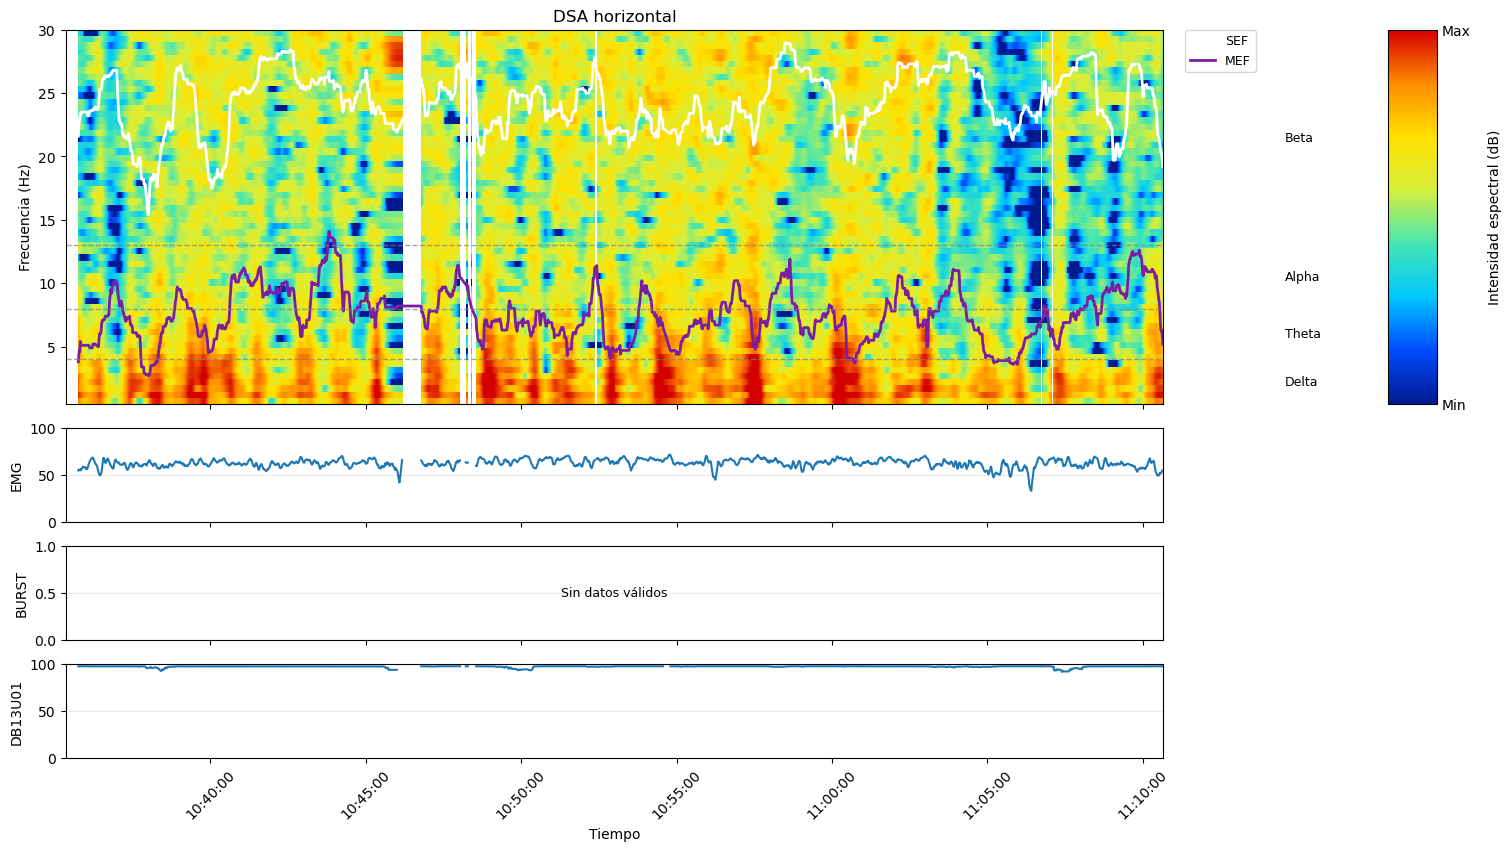

In [53]:
_ = fun_dsa.figura_dsa_y_variables_alineadas(
    tiempo,
    dsa,
    df_spa_unilat,
    umbral_sqi=14,
    incluir=("EMGLOW01", "BURST", "DB13U01")
)

### archivo r2a

In [22]:
archivos_r2a = glob.glob(os.path.join(ruta_base_advanced, "**", "*.r2a"), recursive=True)

In [23]:
archivo_r2a = r"../data/data_bis_advanced/M-TA6m-03041035/DH03041035/L03041035.r2a"

# Al abrir el archivo, leemos directamente solo los primeros 32 bytes
with open(archivo_r2a, "rb") as archivo:
    primeros_bytes = archivo.read(32)

print("Datos en bruto (Hexadecimal):")
print(primeros_bytes.hex(' '))

Datos en bruto (Hexadecimal):
42 f4 ce f3 f2 f3 cb f2 27 f5 24 f4 69 f4 d6 f4 1e f4 0a f4 46 f4 43 f4 d4 f4 d8 f3 db f5 6e f3


#### Despiece

El manual dice que se ocupan 16 bits a 256 muestras/segundo, pero no aclara explícitamente si eso es por canal o total del módulo. Como el archivo es de 2 canales y la duración real solo cuadra usando 128 Hz por canal, la interpretación más razonable es que el módulo genera 256 muestras/s en total, repartidas como 128 muestras/s por cada uno de los dos canales del archivo r2a.

Se sacan 32 bytes:
 - El monitor graba en 16 bits (2 bytes)
 - El archivo guarda 2 canales entrelazados
 - Se tiene que agrupar de 4 en 4 bytes (2 bytes para el canal 1 y 2 para el canal 2)

Separar los 32 bytes en grupos de 4, obtobtener las primeras 8 muestras:
 - Muestra 1: 42 f4 (Canal 1) | ce f3 (Canal 2)
 - Muestra 2: f2 f3 (Canal 1) | cb f2 (Canal 2)
 - Muestra 3: 27 f5 (Canal 1) | 24 f4 (Canal 2)
 - Muestra 4: 69 f4 (Canal 1) | d6 f4 (Canal 2)

Cada lectura de 4 bytes representa un instante temporal del registro:
- 2 bytes: muestra del canal 1
- 2 bytes: muestra del canal 2

Por tanto, el archivo contiene frames de muestreo de 2 canales entrelazados.
Si el caso dura aproximadamente 35 minutos y el archivo contiene 271312 frames,
la frecuencia temporal compatible es de ~128 frames/s, es decir, 128 muestras/s por canal.

In [24]:
# meter la "r" antes para que lea la ruta tal cual por si hay caracteres especiales
archivo_entrada = r"../data/data_bis_advanced/M-TA6m-03041035/DH03041035/L03041035.r2a"
archivo_salida = "voltajes_cerebrales_final.csv"

In [25]:
fau.traducir_r2a(archivo_entrada, archivo_salida)

Se procesaron 271312 muestras por canal.
Tiempo total real: 2119.62 segundos.


El archivo .r2a almacena las señales EEG crudas en formato binario con estructura intercalada. En registros de 2 canales, cada instante temporal está formado por dos enteros consecutivos de 16 bits con signo: primero el valor del canal 1 y después el del canal 2. Por tanto, cada frame ocupa 4 bytes. En registros de 4 canales, el patrón de almacenamiento sigue el orden canal 1, canal 2, canal 3 y canal 4, repitiéndose secuencialmente para cada instante de muestreo.

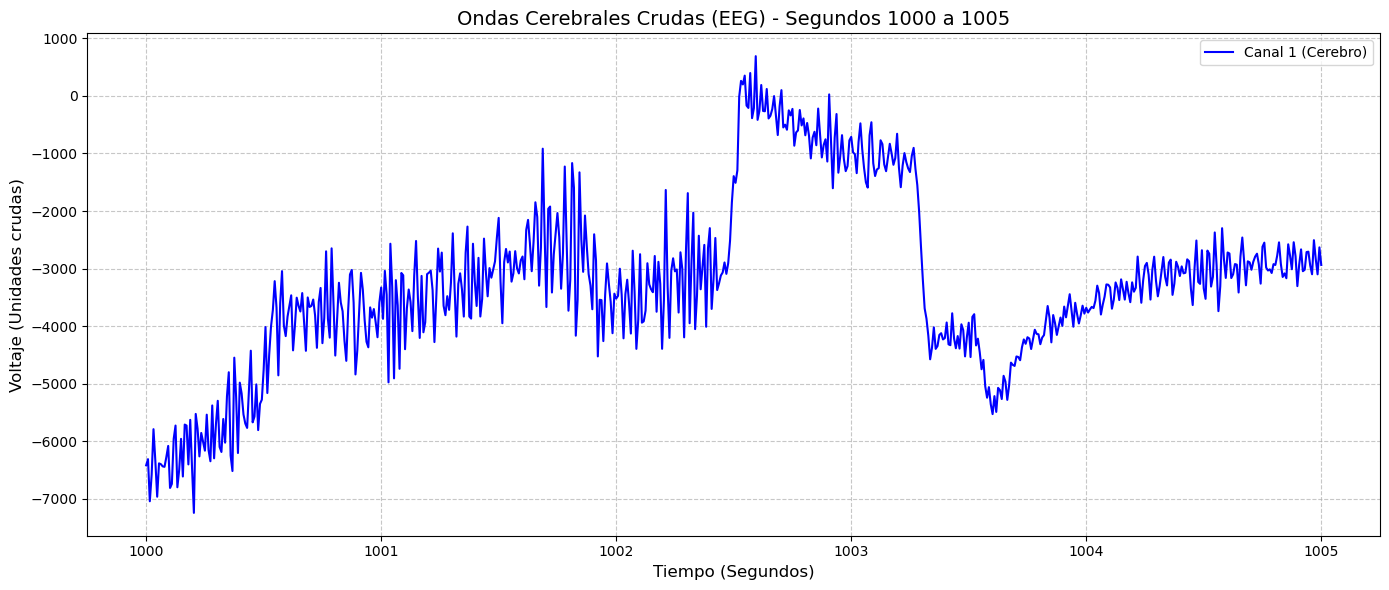

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar archivo CSV
df = pd.read_csv("voltajes_cerebrales_final.csv")

# Elegir ventana de tiempo 
t_inicio = 1000
t_fin = 1005

# Filtramos los datos para coger solo la ventana
df_ventana = df[(df['Tiempo_s'] >= t_inicio) & (df['Tiempo_s'] <= t_fin)]

# crear tamaño figura
plt.figure(figsize=(14, 6))

# dibujar la línea del Canal 1 (cerebro real)
plt.plot(df_ventana['Tiempo_s'], df_ventana['Canal_1'], color='blue', linewidth=1.5, label='Canal 1 (Cerebro)')

# títulos, etiquetas y cuadrícula
plt.title(f'Ondas Cerebrales Crudas (EEG) - Segundos {t_inicio} a {t_fin}', fontsize=14)
plt.xlabel('Tiempo (Segundos)', fontsize=12)
plt.ylabel('Voltaje (Unidades crudas)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper right')

# Guardar la imagen
plt.tight_layout()
# plt.savefig(f'mis_ondas_eeg_{t_inicio}_a_{t_fin}.png', dpi=300)
plt.show()


### archivo .h_a

In [27]:
archivo_bin = "../data/data_bis_advanced/M-TA6m-03041035/DH03041035/L03041035.h_a" 

with open(archivo_bin, "rb") as archivo:
    contenido = archivo.read()

# 2. Vamos a ver los primeros 32 bytes en hexadecimal, separados por espacios
primeros_bytes = contenido[:32]
print("Datos en bruto (Hexadecimal):")
# print(contenido.hex(' '))

Datos en bruto (Hexadecimal):


In [28]:
fau.lectura_h_a(archivo_bin)

ARCHIVO DE CABECERA (.h_a)
--------------------------------------------------
Nombre del archivo:      L03041035.h_a
Hora de inicio deducida: 10:35:
Motor del algoritmo:     BIS-R2
Configuración de Filtro: 0.05 Hz


#### Datos extraídos del Encabezado (.h_a)
 - Nombre del archivo: L03041035.h_a

 - Fecha de inicio de la prueba: 4 de Marzo de 2026 a las 10:35:28 (Hora GMT)

 - Fecha de fin de la prueba: 4 de Marzo de 2026 a las 11:10:45 (Hora GMT)

 - Duración total calculada: 35 minutos y 17 segundos.

 - Motor/Algoritmo del monitor: BIS-R2 (Aparece repetido varias veces en la memoria, indicando la versión del software).

 - Filtro de paso alto configurado: 0.05 Hz (Aparece configurado para los canales internos).

 - Zona Horaria: GMT (Aparece explícitamente escrito casi al final del bloque).

## Dudas teoría Manual BIS Advanced

#### Microvoltios o Decibelios
El archivo crudo (.r2a) es puramente físico: 
 - En la página 32 del manual, define la Amplitud del EEG como la "tensión máxima absoluta de la forma de onda" y especifica claramente que "se expresa en microvoltios (µV)". Por tanto, esos números gigantes que extraíamos del .r2a eran efectivamente subidas y bajadas de microvoltaje puro. 


Las tablas .spa son matemáticas (dB): 
 - El manual confirma en la misma página que el EMG (y consecuentemente la potencia total) "se expresa en decibelios (dB) relativos a 0,0001 µV2". La máquina mide la electricidad bruta en el .r2a (microvoltios) y luego usa ecuaciones complejas para escupir resúmenes en decibelios en el .spa.

#### Tipos de archivos

.r2a y .r4a (EEG sin procesar): 
 - El manual aclara que la "r" es de Raw y el número indica los canales. 
 - El .r2a es para el sistema de 2 canales y el .r4a se genera cuando te ponen el sensor de 4 canales (Bilateral).


.spa (Archivo de variables procesadas): 
 - Aquí enumera que guarda el Índice Biespectral, el EMG, la Calidad de la Señal (ICS) y la Impedancia. Es exactamente la tabla inmensa de Pandas.


.h_a (El Encabezado): 
 - Números hexadecimales. 
 - .h_a incluye: la hora actual del monitor, la revisión de software, 4 números seguidos de -1, el tamaño del archivo crudo, y hora actual en hora Epoch/Unix.


## BIS ANTIGUO

### BIS BILATERAL


En la distribución del sensor Bilateral, los canales se asignan de la siguiente manera:

Canal 1: Temporal Izquierdo (LT)

Canal 2: Ojo Izquierdo (LE)

Canal 3: Temporal Derecho (RT)

Canal 4: Ojo Derecho (RE)

In [29]:
ruta_spa_antiguo = "..\data\data_bis_antiguo\L04141330\L04141330.spa"
df_spa_antiguo = fau.procesar_spa(ruta_spa_antiguo)

display(df_spa_antiguo.head())
print(df_spa_antiguo.shape)
print(df_spa_antiguo.columns.tolist())

,Time,SpSmooth,BiSmooth,LoFilter,NotFiltr,HiFilter,PIC_ID,SR12,SEF08,MEDFRQ08,...,C1POSIMP,C1NEGIMP,GNDIMP,C2POSIMP,C2NEGIMP,C3POSIMP,C3NEGIMP,C4POSIMP,C4NEGIMP,BILBITS
0,2026-04-14 13:30:44,3,0,3,3,2,147,0.0,13.4,2.2,...,,,,,,,,,,3
1,2026-04-14 13:30:45,3,0,3,3,2,147,0.0,13.8,2.2,...,,,,,,,,,,3
2,2026-04-14 13:30:46,3,0,3,3,2,147,0.0,14.3,2.3,...,,,,,,,,,,3
3,2026-04-14 13:30:47,3,0,3,3,2,147,0.0,14.6,2.4,...,,,,,,,,,,3
4,2026-04-14 13:30:48,3,0,3,3,2,147,0.0,14.6,2.4,...,,,,,,,,,,3


(5766, 97)
['Time', 'SpSmooth', 'BiSmooth', 'LoFilter', 'NotFiltr', 'HiFilter', 'PIC_ID', 'SR12', 'SEF08', 'MEDFRQ08', 'BISBIT00', 'DB13U01', 'DB11U04', 'B34U05', 'TOTPOW08', 'EMGLOW01', 'SQI10', 'IMPEDNCE', 'ARTF2', 'BURST', 'ST', 'ASYM09', 'SBIS01', 'SEMG01', 'RESVR0', 'RESVR1', 'RESVR2', 'SR12_2', 'SEF08_2', 'MEDFRQ08_2', 'BISBIT00_2', 'DB13U01_2', 'DB11U04_2', 'B34U05_2', 'TOTPOW08_2', 'EMGLOW01_2', 'SQI10_2', 'IMPEDNCE_2', 'ARTF2_2', 'BURST_2', 'ST_2', 'ASYM09_2', 'SBIS01_2', 'SEMG01_2', 'RESVR0_2', 'RESVR1_2', 'RESVR2_2', 'SR12_3', 'SEF08_3', 'MEDFRQ08_3', 'BISBIT00_3', 'DB13U01_3', 'DB11U04_3', 'B34U05_3', 'TOTPOW08_3', 'EMGLOW01_3', 'SQI10_3', 'IMPEDNCE_3', 'ARTF2_3', 'BURST_3', 'ST_3', 'ASYM09_3', 'SBIS01_3', 'SEMG01_3', 'RESVR0_3', 'RESVR1_3', 'RESVR2_3', 'SR12_4', 'SEF08_4', 'MEDFRQ08_4', 'BISBIT00_4', 'DB13U01_4', 'DB11U04_4', 'B34U05_4', 'TOTPOW08_4', 'EMGLOW01_4', 'SQI10_4', 'IMPEDNCE_4', 'ARTF2_4', 'BURST_4', 'ST_4', 'ASYM09_4', 'SBIS01_4', 'SEMG01_4', 'RESVR0_4', 'RESVR

In [30]:
# Contar cuántos segundos se han grabado
print(df_spa_antiguo.shape[0])

5766


#### Comprobación de valores de campos pre-limpieza

In [31]:
busqueda= fau.buscar_filas_por_valor(df_spa_antiguo, "SEMG01_3", ">", 0)


--- Buscando filas donde SEMG01_3 > 0 ---


,Time,SpSmooth,BiSmooth,LoFilter,NotFiltr,HiFilter,PIC_ID,SR12,SEF08,MEDFRQ08,...,C1POSIMP,C1NEGIMP,GNDIMP,C2POSIMP,C2NEGIMP,C3POSIMP,C3NEGIMP,C4POSIMP,C4NEGIMP,BILBITS
154,2026-04-14 13:33:18,3,0,3,3,2,147,0.0,14.5,2.9,...,,,,,,,,,,3
155,2026-04-14 13:33:19,3,0,3,3,2,147,0.0,15.1,3.1,...,,,,,,,,,,3
156,2026-04-14 13:33:20,3,0,3,3,2,147,0.0,15.1,3.1,...,,,,,,,,,,3
157,2026-04-14 13:33:21,3,0,3,3,2,147,0.0,15.1,3.1,...,,,,,,,,,,3
158,2026-04-14 13:33:22,3,0,3,3,2,147,0.0,15.1,3.1,...,,,,,,,,,,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1662,2026-04-14 13:58:26,3,0,3,3,2,147,0.0,21.7,3.7,...,,,,,,,,,,3
1701,2026-04-14 13:59:05,3,0,3,3,2,147,0.0,20.8,3.5,...,,,,,,,,,,3
1702,2026-04-14 13:59:06,3,0,3,3,2,147,0.0,20.7,3.5,...,,,,,,,,,,3
1703,2026-04-14 13:59:07,3,0,3,3,2,147,0.0,20.7,3.5,...,,,,,,,,,,3


In [32]:
busqueda[["Time", "SQI10", "SQI10_3", "TOTPOW08", "TOTPOW08_3", "ASYM09", "SBIS01", "SBIS01_3", "SEMG01", "SEMG01_3"]]

,Time,SQI10,SQI10_3,TOTPOW08,TOTPOW08_3,ASYM09,SBIS01,SBIS01_3,SEMG01,SEMG01_3
154,2026-04-14 13:33:18,65.4,55.8,67.9,66.5,44.1,3.9,1.6,-3276.8,0.1
155,2026-04-14 13:33:19,66.7,57.1,67.7,66.3,44.1,3.9,1.6,-3276.8,0.1
156,2026-04-14 13:33:20,66.0,57.1,67.7,66.3,44.1,3.9,1.7,-3276.8,0.1
157,2026-04-14 13:33:21,64.7,57.1,67.7,66.3,44.1,3.9,1.7,-3276.8,0.1
158,2026-04-14 13:33:22,63.5,57.1,67.7,66.3,44.1,3.9,1.7,-3276.8,0.1
...,...,...,...,...,...,...,...,...,...,...
1662,2026-04-14 13:58:26,78.8,60.3,63.3,64.4,57.1,1.5,0.1,0.1,0.3
1701,2026-04-14 13:59:05,85.9,82.1,63.8,64.0,48.8,1.1,0.6,1.0,0.2
1702,2026-04-14 13:59:06,85.9,82.1,64.0,64.1,49.5,1.1,0.6,0.2,0.2
1703,2026-04-14 13:59:07,84.6,81.4,64.0,64.1,49.5,1.1,0.5,0.3,0.3


**Mantener Canal 1 y 3 (sin sufijo y el _3)**

 - Canal 1 (campos sin sufijo): Contiene todos los cálculos matemáticos (BIS, Tasa de Supresión, SEF, Burst, etc.) correspondientes al Hemisferio Izquierdo.

 - Canal 3 (campos acabados en _3): Contiene exactamente los mismos cálculos, pero evaluados para el Hemisferio Derecho.

Conservar ambos bloques (Ch 1 y Ch 3) para poder ver y comparar la evolución de los números BIS del lado izquierdo frente al lado derecho.


**Descartar Canal 2 (_2) y el Canal 4 (_4)**

 - Las variables procesadas complejas (como el número BIS o el EMG) no se calculan de forma aislada para los ojos, por lo que en tus datos verás que están rellenas con el código de error -3276.8.
 
Borrar todas las columnas que acaben en _2 y _4, a menos que interese conservar la Calidad de Señal (SQI) o la Impedancia física específica de esos electrodos frontales. 

**No borrar las variables exclusivas bilaterales**

In [33]:
#busqueda[["Time", "SQI10", "SQI10_2", "SQI10_3", "SQI10_4", "TOTPOW08","TOTPOW08_2", "TOTPOW08_3", "TOTPOW08_4"]]

In [34]:
#busqueda[["Time", "SQI10", "SQI10_2", "SQI10_3", "SQI10_4", "EMGLOW01","EMGLOW01_2", "EMGLOW01_3", "EMGLOW01_4"]]

In [35]:
#busqueda[["Time", "SQI10", "SQI10_2", "SQI10_3", "SQI10_4", "ASYM09", "SBIS01", "SBIS01_3", "SEMG01", "SEMG01_3"]]

**Variabilidad del BIS y del EMG**

SBIS (Variabilidad del BIS): Es la desviación estándar del valor BIS a lo largo del último minuto. Te indica cuánto está fluctuando o cambiando el número BIS en ese hemisferio.

SEMG (Variabilidad del EMG): Es la desviación estándar de la actividad muscular (EMG) a lo largo del último minuto. Te indica cuánto está variando el tono muscular o la tensión frontal.

#### Exploración variables del Bilateral 4 canales

In [36]:
#display(df_spa_antiguo.iloc[300: 340: 2, :20])

In [37]:
#display(df_spa_antiguo.iloc[300: 340: 2, 20:27])

In [38]:
#display(df_spa_antiguo.iloc[300: 340: 2, 27:42])

In [39]:
#display(df_spa_antiguo.iloc[300: 340: 2, 42:47])

In [40]:
#display(df_spa_antiguo.iloc[300: 340: 2, 47:62])

In [41]:
#display(df_spa_antiguo.iloc[300: 340: 2, 62:67])

In [42]:
#display(df_spa_antiguo.iloc[300: 340: 2, 67:82])

In [43]:
#display(df_spa_antiguo.iloc[300: 340: 2, 82:])

#### Limpieza

In [44]:
import funciones_aux

df_spa_limpio = fau.limpiar_spa_bilateral(df_spa_antiguo)

# Comprobamos cómo ha quedado el "antes y después"
print(f"\nForma ANTES de limpiar:  {df_spa_antiguo.shape}")
print(f"Forma DESPUÉS de limpiar: {df_spa_limpio.shape}")

print("\nNuevas columnas limpias listas para el análisis clínico:")
print(df_spa_limpio.columns.tolist())

Iniciando limpieza del archivo .spa...
Se han eliminado 57 columnas basura.

Forma ANTES de limpiar:  (5766, 97)
Forma DESPUÉS de limpiar: (5766, 40)

Nuevas columnas limpias listas para el análisis clínico:
['Time', 'SpSmooth', 'BiSmooth', 'LoFilter', 'NotFiltr', 'HiFilter', 'PIC_ID', 'SR12', 'SEF08', 'MEDFRQ08', 'BISBIT00', 'DB13U01', 'DB11U04', 'B34U05', 'TOTPOW08', 'EMGLOW01', 'SQI10', 'IMPEDNCE', 'ARTF2', 'BURST', 'ST', 'ASYM09', 'SBIS01', 'SEMG01', 'SR12_3', 'SEF08_3', 'MEDFRQ08_3', 'BISBIT00_3', 'DB13U01_3', 'DB11U04_3', 'B34U05_3', 'TOTPOW08_3', 'EMGLOW01_3', 'SQI10_3', 'IMPEDNCE_3', 'ARTF2_3', 'BURST_3', 'ST_3', 'SBIS01_3', 'SEMG01_3']


In [45]:
#display(df_spa_limpio.iloc[300: 340: 2, :20])

In [46]:
#display(df_spa_limpio.iloc[300: 340: 2, 20:])

#### Tratamiento valores BIS

In [47]:
import numpy as np

# 1. Extraemos el Tiempo y las 4 columnas clave (Crudo y Suavizado de cada lado)
df_bis_pantalla = df_spa_limpio[['Time', 'DB13U01', 'DB13U01_3']].copy()

# 2. Renombramos para que cualquiera pueda entender la tabla
df_bis_pantalla.columns = ['Tiempo', 'Izq_BIS_Crudo', 'Der_BIS_Crudo']

# 3. Limpiamos los -3276.8 (los segundos iniciales donde no había señal)
df_bis_pantalla.replace(-3276.8, np.nan, inplace=True)

display(df_bis_pantalla.head(15))

,Tiempo,Izq_BIS_Crudo,Der_BIS_Crudo
0,2026-04-14 13:30:44,97.7,91.0
1,2026-04-14 13:30:45,97.7,92.8
2,2026-04-14 13:30:46,97.7,95.5
3,2026-04-14 13:30:47,97.7,97.2
4,2026-04-14 13:30:48,97.7,97.5
5,2026-04-14 13:30:49,97.7,97.4
6,2026-04-14 13:30:50,97.7,97.4
7,2026-04-14 13:30:51,97.7,97.4
8,2026-04-14 13:30:52,97.7,97.4
9,2026-04-14 13:30:53,97.7,97.4


En el archivo de texto, el campo correspondiente al valor verdadero del BIS suele aparecer etiquetado en el encabezado como B34... o DB1... (dependiendo del tipo de sensor), y da un valor decimal entre 0.0 y 100.0.

-----------------------------------------------------------------------------------------------------------------

**El archivo .spa está programado para organizar los datos de esta manera:**

 - Los campos acabados en _1 (Canal 1): Agrupan todos los cálculos del Hemisferio Izquierdo. (Combina las señales del Temporal Izquierdo y el Ojo Izquierdo).
 - Los campos acabados en _3 (Canal 3): Agrupan todos los cálculos del Hemisferio Derecho. (Combina las señales del Temporal Derecho y el Ojo Derecho).


Es totalmente normal que solo haya valores válidos para las variables cerebrales complejas (como el BIS, SEF, Burst, TOTPOW, etc.) en las columnas _1 y _3. 

El manual estipula que los cálculos cognitivos se realizan por hemisferio completo (Canal 1 para el Izquierdo y Canal 3 para el Derecho), por lo que el algoritmo rellena con códigos de "valor inválido" (como -3276.8) esos campos matemáticos en los canales 2 y 4. 

Las únicas excepciones que conservan valores reales en los canales 2 y 4 son las medidas físicas directas del electrodo: el SQI (Calidad de Señal) y la Impedancia (IMPEDNCE).


**Por qué SQI10_2 y SQI10_4 son exactamente iguales**

 - El manual define el Índice de Calidad de Señal (SQI) como una medida que se calcula basándose en los datos de impedancia, los artefactos (interferencias) y otras variables propias de ese canal.

Que los valores de SQI10_2 y SQI10_4 sean idénticos se explica por la anatomía de la monitorización y cómo el sistema gestiona el ruido:

 - Ubicación y Artefactos Simétricos: El Canal 2 corresponde al electrodo del Ojo Izquierdo (LE) y el Canal 4 al del Ojo Derecho (RE). Los "artefactos" o ruidos que más penalizan el SQI en esa zona de la cara son los movimientos oculares, el parpadeo y la tensión muscular frontal. Dado que los humanos parpadeamos y movemos los ojos de forma simétrica, ambos electrodos sufren la misma interferencia exactamente al mismo tiempo, haciendo que el algoritmo reduzca o mantenga su índice de calidad a la par.

 - Referencia Central Compartida: En el sensor de 6 pegatinas, los electrodos de los ojos miden su señal tomando como referencia la pegatina central C (Centro) y la de tierra G (Ground). Cualquier fluctuación o ruido en esa zona central común afectará matemáticamente a la fórmula del SQI de ambos ojos por igual.

-------------------------------------------------------------------------------------------------------------------------

### .r4a ondas crudas Bilateral 4 canales

**Formato de los datos (El tipo de variable)**

Cada muestra individual del EEG se guarda como un número entero con signo de 16 bits (16-bit signed integer) en formato de complemento a 2.


**Estructura intercalada (Multiplexación)**

Los canales no vienen separados en bloques, sino que se escriben de forma secuencial y repetitiva (intercalados muestra por muestra).
 - Al ser un archivo .r4a (4 canales), el orden de lectura de cada bloque de 16 bits es:
Canal 1 → Canal 2 → Canal 3 → Canal 4 → Canal 1 → Canal 2... y así sucesivamente hasta el final del archivo.


**Frecuencia de muestreo**

 - Toma 128 muestras por segundo para cada canal (128 Hz).
 - Esto significa que, por cada segundo de grabación física, el programa deberá leer 512 valores en total (128 muestras x 4 canales).
 
 
**Conversión a Microvoltios (La escala)**

 - El número entero que leas del archivo no es el voltaje directo. El manual especifica que los valores están en unidades de 0.05 µV.
 - Fórmula de procesamiento: Para obtener la amplitud real de la onda cerebral, debes coger el número entero extraído y multiplicarlo por 0.05. El resultado será el valor de la onda en microvoltios (µV).
 

**Manejo de errores o "huecos"**

 - Si se pierden paquetes de datos, el equipo mantiene la sincronización temporal del archivo rellenando ese hueco con datos de amplitud cero (0).

In [48]:
def convertir_r4a_a_csv(archivo_entrada, archivo_salida):
    """
    Convierte un archivo de ondas crudas .r4a (Bilateral, 4 canales) a formato CSV.
    Basado en las especificaciones del monitor BIS: 
    - 128 muestras por segundo (Hz).
    - Los valores enteros se multiplican por 0.05 para obtener microvoltios (µV).
    
    Parámetros:
    - archivo_entrada (str): Ruta al archivo .r4a que se desea leer.
    - archivo_salida (str): Ruta donde se guardará el archivo .csv resultante.
    """
    print(f"Iniciando conversión de ondas crudas (BIS Bilateral) a 128 Hz...")
    print(f"Archivo origen: {archivo_entrada}")
    
    try:
        with open(archivo_entrada, "rb") as f_in, open(archivo_salida, "w") as f_out:
            # 1. Escribimos la cabecera indicando las unidades en microvoltios
            f_out.write("Tiempo_s,Canal_1_uV,Canal_2_uV,Canal_3_uV,Canal_4_uV\n")
            
            contador_muestras = 0
            
            # 2. Bucle de lectura de 8 en 8 bytes (4 canales * 2 bytes/canal)
            while True:
                bytes_muestra = f_in.read(8)
                if not bytes_muestra or len(bytes_muestra) < 8:
                    break
                
                # 3. Desempaquetar 4 enteros de 16 bits con signo ('<hhhh')
                canal_1, canal_2, canal_3, canal_4 = struct.unpack('<hhhh', bytes_muestra)
                
                # 4. Convertir a microvoltios (µV) multiplicando por 0.05
                c1_uv = canal_1 * 0.05
                c2_uv = canal_2 * 0.05
                c3_uv = canal_3 * 0.05
                c4_uv = canal_4 * 0.05
                
                # 5. Calcular tiempo en segundos usando la frecuencia de muestreo (128 Hz)
                tiempo_en_segundos = contador_muestras / 128.0
                
                # 6. Escribir en el CSV con 4 decimales de precisión
                f_out.write(f"{tiempo_en_segundos:.4f},{c1_uv:.4f},{c2_uv:.4f},{c3_uv:.4f},{c4_uv:.4f}\n")
                
                contador_muestras += 1

        print(f"- Muestras por canal procesadas: {contador_muestras}")
        print(f"- Tiempo total del registro: {contador_muestras / 128.0:.2f} segundos.")
        print(f"- Archivo guardado en: {os.path.abspath(archivo_salida)}\n")

    except FileNotFoundError:
        print(f"Error: No se encontró el archivo '{archivo_entrada}'. Por favor, verifica la ruta.\n")
    except Exception as e:
        print(f"Ocurrió un error inesperado al procesar el archivo: {e}\n")


In [49]:
archivo_entrada = r"..\data\data_bis_antiguo\L04141330\L04141330.r4a"
archivo_salida = "voltajes_bilaterales.csv"

convertir_r4a_a_csv(archivo_entrada, archivo_salida)

Iniciando conversión de ondas crudas (BIS Bilateral) a 128 Hz...
Archivo origen: ..\data\data_bis_antiguo\L04141330\L04141330.r4a
- Muestras por canal procesadas: 737280
- Tiempo total del registro: 5760.00 segundos.
- Archivo guardado en: C:\Users\usuario\TFG_BIS_GIS\notebooks\voltajes_bilaterales.csv



1. La escala de tiempo (Tiempo_s)
 El equipo graba a una velocidad de 128 hercios (Hz). Esto significa que, por cada segundo que pasó en la realidad, hay 128 filas de datos.
 - Va avanzando en saltos de 0.0078 segundos (0.0000, 0.0078, 0.0156, etc.).
 
 
2. El mapa anatómico (Los canales)
Según el manual de especificaciones del sensor Bilateral, cada columna numérica corresponde a una pegatina específica en tu frente:

 - Canal_1_uV (LT - Temporal Izquierdo): Recoge la actividad cerebral de la sien izquierda.
 - Canal_2_uV (LE - Ojo Izquierdo): Recoge la actividad eléctrica por encima del ojo o ceja izquierda.
 - Canal_3_uV (RT - Temporal Derecho): Recoge la actividad cerebral de la sien derecha.
 - Canal_4_uV (RE - Ojo Derecho): Recoge la actividad eléctrica por encima del ojo o ceja derecha.
 

3. Los valores (_uV)
Los números que ves (por ejemplo, 12.4500 o -5.3000) son la amplitud del voltaje eléctrico medido en tu piel en ese milisegundo exacto, expresado en microvoltios (µV). Al ser ondas "crudas", este voltaje es una mezcla de varias cosas:

 - La electricidad generada por tus neuronas (las verdaderas ondas cerebrales).
 - La electricidad generada por tus músculos faciales (EMG).
 - El ruido eléctrico del ambiente (como la corriente de los enchufes a 50Hz o 60Hz).

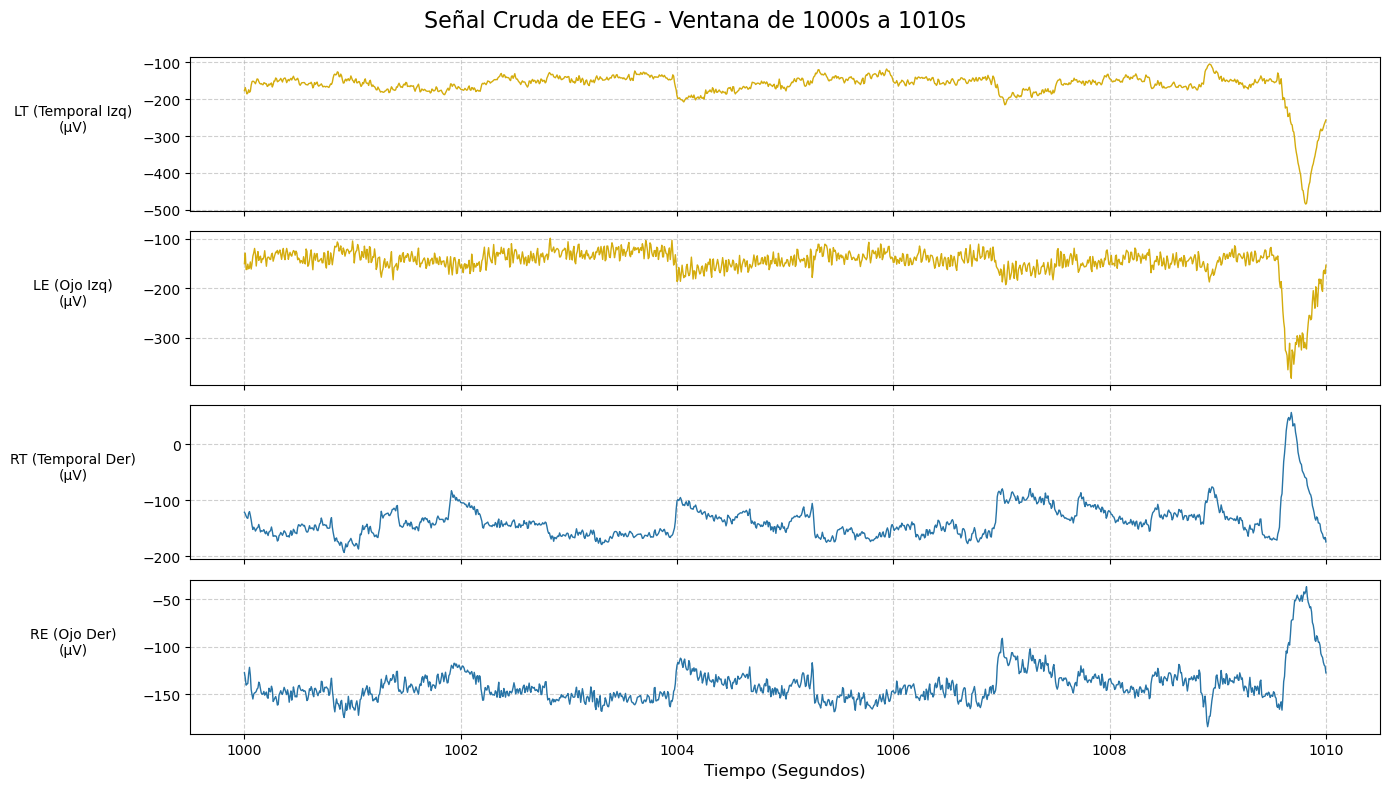

In [50]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Cargar los datos convertidos
archivo_csv = "voltajes_bilaterales.csv"
df = pd.read_csv(archivo_csv)

# 2. Definir una "ventana de tiempo" para hacer zoom (ej: 10 segundos)
# Puedes cambiar estos valores para explorar diferentes momentos de la cirugía
inicio_segundos = 1000 
fin_segundos = 1010

# Filtramos el dataframe para quedarnos solo con esa ventana
df_ventana = df[(df['Tiempo_s'] >= inicio_segundos) & (df['Tiempo_s'] <= fin_segundos)]

# 3. Configurar el estilo del gráfico "en plan EEG"
# Creamos 4 subgráficos apilados verticalmente que comparten el eje X (Tiempo)
fig, axs = plt.subplots(4, 1, figsize=(14, 8), sharex=True)
fig.suptitle(f'Señal Cruda de EEG - Ventana de {inicio_segundos}s a {fin_segundos}s', fontsize=16)

# Nombres de las columnas en tu CSV
canales = ['Canal_1_uV', 'Canal_2_uV', 'Canal_3_uV', 'Canal_4_uV']

# Detalle estético del monitor VISTA: Izquierda en amarillo, Derecha en azul
colores = ['#D4AC0D', '#D4AC0D', '#2874A6', '#2874A6']
nombres_clinicos = ['LT (Temporal Izq)', 'LE (Ojo Izq)', 'RT (Temporal Der)', 'RE (Ojo Der)']

# 4. Dibujar cada canal en su respectivo subgráfico
for i in range(4):
    axs[i].plot(df_ventana['Tiempo_s'], df_ventana[canales[i]], color=colores[i], linewidth=1)
    
    # Configuraciones estéticas para cada fila
    axs[i].set_ylabel(f'{nombres_clinicos[i]}\n(µV)', rotation=0, labelpad=50, ha='center', fontsize=10)
    axs[i].grid(True, linestyle='--', alpha=0.6)
    
    # Opcional: Fijar los límites del eje Y (ej. entre -100 y 100 µV) para evitar 
    # que un parpadeo deforme la escala, pero de momento dejamos que se autoajuste.
    # axs[i].set_ylim(-100, 100)

# Etiqueta del eje X solo en el último gráfico
axs[-1].set_xlabel('Tiempo (Segundos)', fontsize=12)

plt.tight_layout()
plt.subplots_adjust(top=0.92) # Ajuste para que el título no se superponga
plt.show()

Es un error muy común al empezar a analizar señales biológicas, pero los microvoltios (µV) y los hercios (Hz) miden dos dimensiones completamente distintas de la física:

Los Microvoltios (µV): Miden la amplitud o fuerza eléctrica de la onda en un instante exacto. Te dicen "qué tan alto o bajo" es el pico de electricidad.

Los Hercios (Hz): Miden la frecuencia. Te dicen "cuántas veces" se repite esa onda en un segundo.

Transformación de Dominio
Lo que tú realmente necesitas hacer no es un "cambio de unidades", sino aplicar una operación matemática a todo el bloque de datos llamada Transformada Rápida de Fourier (FFT). Esta operación coge los miles de microvoltios de tu CSV y extrae las frecuencias (Hz) que están escondidas dentro de esos picos y valles.

Aquí tienes el script en Python para leer ese CSV que creamos antes, extraer exactamente los Hz de tu Canal 1 (Hemisferio Izquierdo) y calcular el porcentaje de cada tipo de onda cerebral que tenías en ese momento:

In [51]:
import pandas as pd
import numpy as np
from scipy import signal

# 1. Cargar el archivo con las ondas crudas
archivo_csv = "voltajes_bilaterales.csv"
print("Cargando datos...")
df = pd.read_csv(archivo_csv)

# Vamos a analizar el Canal 1 (LT - Temporal Izquierdo)
# (Puedes cambiarlo al Canal 3 si quieres analizar el lado derecho)
canal_analizar = df['Canal_1_uV'].values

# Frecuencia de muestreo dictada por el monitor BIS
fs = 128  

# 2. Aplicar la matemática (Transformada de Fourier mediante método de Welch)
# Esto extrae las frecuencias (Hz) a partir de los voltajes (µV)
frecuencias, psd = signal.welch(canal_analizar, fs, nperseg=1024)

# 3. Definir los rangos de las ondas cerebrales en Hercios (Hz)
bandas_eeg = {
    'Ondas Delta (0.5 - 4 Hz) [Sueño profundo / Anestesia]': (0.5, 4),
    'Ondas Theta (4 - 8 Hz)   [Somnolencia]': (4, 8),
    'Ondas Alfa (8 - 13 Hz)   [Relajación con ojos cerrados]': (8, 13),
    'Ondas Beta (13 - 30 Hz)  [Despierto y concentrado]': (13, 30)
}

potencias_bandas = {}
potencia_total = 0

# 4. Calcular cuánta "energía" hay en cada banda de Hz
for nombre, (fmin, fmax) in bandas_eeg.items():
    # Encontrar qué frecuencias de nuestro cálculo caen en esta banda
    idx_banda = np.logical_and(frecuencias >= fmin, frecuencias <= fmax)
    
    # Calcular el área bajo la curva (potencia real) para esas frecuencias
    potencia_banda = np.trapz(psd[idx_banda], frecuencias[idx_banda])
    
    potencias_bandas[nombre] = potencia_banda
    potencia_total += potencia_banda

# 5. Imprimir los porcentajes
print("\n--- RESULTADOS DEL ELECTROENCEFALOGRAMA ---")
for nombre, potencia in potencias_bandas.items():
    porcentaje = (potencia / potencia_total) * 100
    print(f"{nombre}: {porcentaje:.2f}%")

Cargando datos...

--- RESULTADOS DEL ELECTROENCEFALOGRAMA ---
Ondas Delta (0.5 - 4 Hz) [Sueño profundo / Anestesia]: 80.55%
Ondas Theta (4 - 8 Hz)   [Somnolencia]: 11.29%
Ondas Alfa (8 - 13 Hz)   [Relajación con ojos cerrados]: 4.00%
Ondas Beta (13 - 30 Hz)  [Despierto y concentrado]: 4.16%


En lugar de mirar voltaje por voltaje, coge todo tu historial de la sien izquierda (Canal_1_uV).

Utiliza la función signal.welch para hacer el equivalente a pasar la luz blanca por un prisma: separa la señal compleja en todos los colores (frecuencias en Hz) que la forman.

Suma la cantidad de señal que hay en los rangos médicos conocidos (Delta, Theta, Alfa y Beta).

Te devuelve un porcentaje limpio (ej. 45.20% de Ondas Delta), que te dirá instantáneamente en qué estado de consciencia o relajación se encontraba tu cerebro en esa grabación.